In [1]:
from matplotlib import pyplot as plt
import numpy as np
import math

In [3]:
lambda_seed = 1030e-9 #central wavelength of the Seed pulse
eta_index = 1 #refractive index of the medium
r_input = 24/2#1/e^2 radius of the input beam (Seed output size from the compressor)


theta_in = 0# input divergence of the Seed [rad]; very well collimated!
w_in_x = 8.5e-3 #input beam size along X DIMENSION (1/e^2 intensity radius) [m]
w_in_y = 9.3e-3 #input beam size along Y DIMENSION (1/e^2 intensity radius) [m]
R_in_x = math.inf #input beam curvature along Y DIMENSION
R_in_y = math.inf #input beam curvature along Y DIMENSION

q_in_x = 1/(1/R_in_x-1j*lambda_seed/(np.pi*eta_index*w_in_x**2)) #complex q parameter of the gaussian beam at the input; X dimension
q_in_y = 1/(1/R_in_y-1j*lambda_seed/(np.pi*eta_index*w_in_y**2)) #complex q parameter of the gaussian beam at the input; Y dimension

d_to_scraper = 7935e-3 #distance of the last telescope mirror to the input scraper mirror
d_scraper_to_grid = 7950e-3 #distance from the input scraper to the first grid mirror
d_grid_to_grid = 8000e-3#8173e-3 #distance from grid to grid

R_scraper_in = 8000e-3 #Radius of curvature of the input scraper mirror
R_right = 4000e-3 #radius of curvature of the mirrors on the right grid
R_left = 4000e-3 #radius of curvature of the mirrors on the left grid
R_scraper_out = 12000e-3 #radius of curvature of the output scraper mirror (placed in the right chamber)

f_scraper_in = R_scraper_in/2 #focal length of the input scraper mirror
f_right = R_right/2 #focal length of the right grid mirrors
f_left = R_left/2 #focal length of the right grid mirrors
f_scraper_out = R_scraper_out/2 #focal length of the output scraper mirror (placed in the right chamber)

def ABCD_free(d):
    """ABCD matrix for free-space propagation over distance d."""
    return np.array([[1,d],[0,1]])

def ABCD_mirror(R):
    """ABCD matrix for reflection from a spherical mirror with radius R."""
    f = R / 2
    return np.array([[1, 0], [-1/f, 1]])

def apply_ABCD(M, q):
    """Apply ABCD matrix M to complex q parameter."""
    A = M[0, 0]
    B = M[0, 1]
    C = M[1, 0]
    D = M[1, 1]
    return (A * q + B) / (C * q + D)


def w_from_q(q, wavelength, eta=1.0):
    """Compute beam radius from complex q."""
    Im_1_q = np.imag(1 / q)
    if Im_1_q == 0:
        return np.inf  # perfectly collimated
    return np.sqrt(wavelength / (np.pi * eta * abs(Im_1_q)))

w_x = []#list of beam sizes to be populated (X-dimension)
w_y = []#list of beam sizes to be populated (Y-dimension)
w_foc_x = [] #list of focus sizes to be populated (X-dimension)
w_foc_y = [] #list of focus sizes to be populated (Y-dimension)


q_scraper_in_x = apply_ABCD(M=ABCD_free(d=d_to_scraper),q=q_in_x) #complex beam parameter as incident on the input scraper mirror (X-dimension)
q_scraper_in_y = apply_ABCD(M=ABCD_free(d=d_to_scraper),q=q_in_y) #complex beam parameter as incident on the input scraper mirror (Y-dimension)

w_scraper_in_x = w_from_q(q=q_scraper_in_x,wavelength=lambda_seed,eta=eta_index) #find the beam radius on the input scraper mirror (X-dimension)
w_scraper_in_y = w_from_q(q=q_scraper_in_y,wavelength=lambda_seed,eta=eta_index) #find the beam radius on the input scraper mirror (Y-dimension)

w_x.append(w_scraper_in_x) #append the beam sizes array with the beam size at the input scraper
w_y.append(w_scraper_in_y) #append the beam sizes array with the beam size at the input scraper

q_after_scraper_in_x = apply_ABCD(M=ABCD_mirror(R=R_scraper_in),q=q_scraper_in_x)
q_after_scraper_in_y = apply_ABCD(M=ABCD_mirror(R=R_scraper_in),q=q_scraper_in_y)

q_focus_0_x = apply_ABCD(M=ABCD_free(d=d_scraper_to_grid/2),q=q_after_scraper_in_x) #complex beam parameter in the focus created by the input scraper mirror
q_focus_0_y = apply_ABCD(M=ABCD_free(d=d_scraper_to_grid/2),q=q_after_scraper_in_y) #complex beam parameter in the focus created by the input scraper mirror

w_focus_0_x = w_from_q(q=q_focus_0_x, wavelength=lambda_seed, eta=eta_index)
w_focus_0_y = w_from_q(q=q_focus_0_y, wavelength=lambda_seed, eta=eta_index)

w_foc_x.append(w_focus_0_x) #append the focus size (after the input scraper) into the list of focus sizes (X-dimension)
w_foc_y.append(w_focus_0_y) #append the focus size (after the input scraper) into the list of focus sizes (Y-dimension)

q_at_M1_x = apply_ABCD(M=ABCD_free(d=d_scraper_to_grid),q=q_after_scraper_in_x) #complex beam parameter at the first grid mirror (right side); X-dimension
q_at_M1_y = apply_ABCD(M=ABCD_free(d=d_scraper_to_grid),q=q_after_scraper_in_y) #complex beam parameter at the first grid mirror (right side); Y-dimension

w_M1_x = w_from_q(q=q_at_M1_x, wavelength=lambda_seed, eta=eta_index) #beam size on the first grid mirror (right grid); X-dimension
w_M1_y = w_from_q(q=q_at_M1_y, wavelength=lambda_seed, eta=eta_index) #beam size on the first grid mirror (right grid); Y-dimension

w_x.append(w_M1_x) #append the beam sizes list with the beam size at M1 (X)
w_x.append(w_M1_y) #append the beam sizes list with the beam size at M1 (Y)

q_after_M1_x = apply_ABCD(M=ABCD_mirror(R=R_right),q=q_at_M1_x)
q_after_M1_y = apply_ABCD(M=ABCD_mirror(R=R_right),q=q_at_M1_y)




# Total number of mirror hits
num_mirrors = 36

# Start from q_after_M1_x (after the first right grid mirror)
q_current_x = q_after_M1_x
q_current_y = q_after_M1_y

# Loop through remaining mirrors
for i in range(2, num_mirrors + 1):
    # Determine current mirror side
    if i % 2 == 0:
        # Even-numbered mirror: left side
        R_current = R_left
    else:
        # Odd-numbered mirror: right side
        R_current = R_right

    # Propagate to next mirror (grid-to-grid distance)
    q_before_mirror_x = apply_ABCD(ABCD_free(d_grid_to_grid), q_current_x)
    q_before_mirror_y = apply_ABCD(ABCD_free(d_grid_to_grid), q_current_y)

    # Record beam size at mirror
    w_at_mirror_x = w_from_q(q_before_mirror_x, lambda_seed, eta_index)
    w_at_mirror_y = w_from_q(q_before_mirror_y, lambda_seed, eta_index)
    w_x = np.append(w_x, w_at_mirror_x)
    w_y = np.append(w_y, w_at_mirror_y)

    # Apply mirror curvature
    q_after_mirror_x = apply_ABCD(ABCD_mirror(R_current), q_before_mirror_x)
    q_after_mirror_y = apply_ABCD(ABCD_mirror(R_current), q_before_mirror_y)

    # Propagate to focus (midpoint between mirrors)
    q_focus_x = apply_ABCD(ABCD_free(d_grid_to_grid / 2), q_after_mirror_x)
    q_focus_y = apply_ABCD(ABCD_free(d_grid_to_grid / 2), q_after_mirror_y)

    # Record focus size
    w_focus_x = w_from_q(q_focus_x, lambda_seed, eta_index)
    w_focus_y = w_from_q(q_focus_y, lambda_seed, eta_index)
    w_foc_x = np.append(w_foc_x, w_focus_x)
    w_foc_y = np.append(w_foc_y, w_focus_y)

    # Update q for next step
    q_current_x = q_after_mirror_x
    q_current_y = q_after_mirror_y


w_x = np.array(w_x) #cast lists to arrays
w_y = np.array(w_y) #cast lists to arrays
w_foc_x = np.array(w_foc_x)
w_foc_y = np.array(w_foc_y)

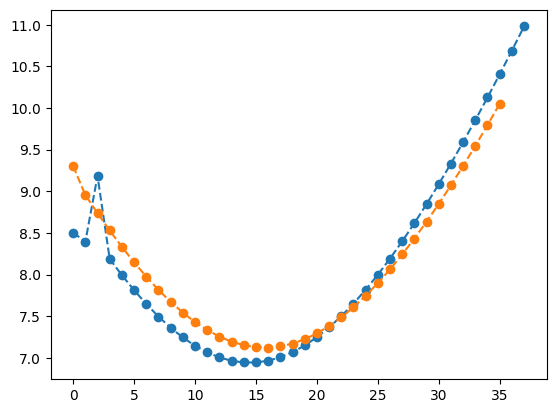

In [4]:
plt.plot(w_x*1e3,'--o')
plt.plot(w_y*1e3,'--o')
#plt.ylim(0,10)